House Price Prediction using Linear Regression

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt

In [3]:
X, y = make_classification(
    n_samples=1000,
    n_features=10,
    n_informative=5,
    n_redundant=2,
    n_classes=2,
    random_state=42
)

In [4]:
columns = [f"feature_{i}" for i in range(1, 11)]
df = pd.DataFrame(X, columns=columns)
df["target"] = y
df.to_csv("ml_example_dataset.csv", index=False)
print("Dataset saved as 'ml_example_dataset.csv'")
print(df.head())
data = pd.read_csv("ml_example_dataset.csv")
print("\nShape of data:", data.shape)
print("\nFirst 5 rows:\n", data.head())
print("\nMissing values in each column:\n", data.isnull().sum())
X = data.drop("target", axis=1)
y = data["target"]

Dataset saved as 'ml_example_dataset.csv'
   feature_1  feature_2  feature_3  feature_4  feature_5  feature_6  \
0   1.125100   1.178124   0.493516   0.790880  -0.614278   1.347020   
1  -0.564641   3.638629  -1.522415  -1.541705   1.616697   4.781310   
2   0.516313   2.165426  -0.628486  -0.386923   0.492518   1.442381   
3   0.537282   0.966618  -0.115420   0.670755  -0.958516   0.871440   
4   0.278385   1.065828  -1.724917  -2.235667   0.715107   0.731249   

   feature_7  feature_8  feature_9  feature_10  target  
0   1.419515   1.357325   0.966041   -1.981139       1  
1   3.190292  -0.890254   1.438826   -3.828748       0  
2   1.332905  -1.958175  -0.348803   -1.804124       0  
3   0.508186  -1.034471  -1.654176   -1.910503       1  
4  -0.674119   0.598330  -0.524283    1.047610       0  

Shape of data: (1000, 11)

First 5 rows:
    feature_1  feature_2  feature_3  feature_4  feature_5  feature_6  \
0   1.125100   1.178124   0.493516   0.790880  -0.614278   1.347020   
1  -

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [6]:
print("\nTrain shape:", X_train.shape, " Test shape:", X_test.shape)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Train shape: (700, 10)  Test shape: (300, 10)


In [7]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5)
}
results = []

In [8]:
for name, model in models.items():
    if name in ["Logistic Regression", "KNN (k=5)"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "ROC-AUC": auc
    })
    print("\n==============================")
    print("Model:", name)
    print("Accuracy    :", acc)
    print("Precision   :", prec)
    print("Recall      :", rec)
    print("F1-Score    :", f1)
    print("ROC-AUC     :", auc)
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:\n", cm)
results_df = pd.DataFrame(results)
print("\n\n===== MODEL PERFORMANCE SUMMARY =====\n")
print(results_df)
best_model_name = results_df.sort_values("Accuracy", ascending=False)["Model"].iloc[0]
print("\nBest model based on Accuracy:", best_model_name)
best_model = models[best_model_name]


Model: Logistic Regression
Accuracy    : 0.83
Precision   : 0.8378378378378378
Recall      : 0.8211920529801324
F1-Score    : 0.8294314381270903
ROC-AUC     : 0.9045735366016266

Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.84      0.83       149
           1       0.84      0.82      0.83       151

    accuracy                           0.83       300
   macro avg       0.83      0.83      0.83       300
weighted avg       0.83      0.83      0.83       300

Confusion Matrix:
 [[125  24]
 [ 27 124]]

Model: Random Forest
Accuracy    : 0.9433333333333334
Precision   : 0.935064935064935
Recall      : 0.9536423841059603
F1-Score    : 0.9442622950819672
ROC-AUC     : 0.990066225165563

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.93      0.94       149
           1       0.94      0.95      0.94       151

    accuracy                           0.94       300

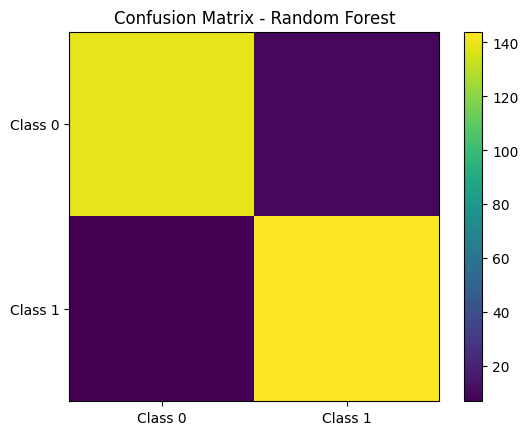

In [9]:
if best_model_name in ["Logistic Regression", "KNN (k=5)"]:
    y_pred_best = best_model.predict(X_test_scaled)
else:
    y_pred_best = best_model.predict(X_test)
cm_best = confusion_matrix(y_test, y_pred_best)
plt.figure()
plt.imshow(cm_best, interpolation="nearest")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ["Class 0", "Class 1"])
plt.yticks(tick_marks, ["Class 0", "Class 1"])
thresh = cm_best.max() / 2.

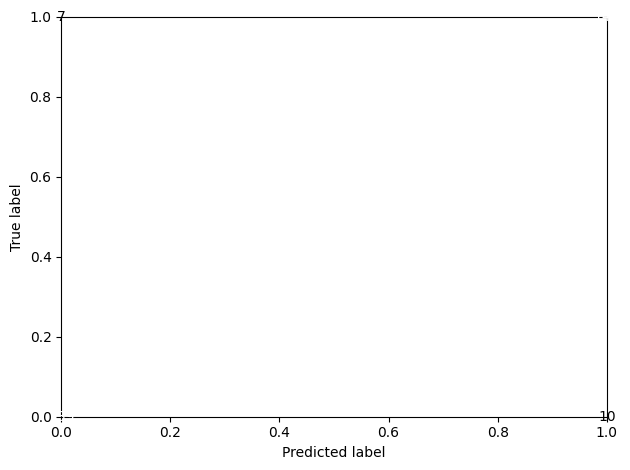

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [11]:
thresh = cm_best.max() / 2.
for i in range(cm_best.shape[0]):
    for j in range(cm_best.shape[1]):
        plt.text(j, i, cm_best[i, j],
                 horizontalalignment="center",
                 verticalalignment="center",
                 color="white" if cm_best[i, j] > thresh else "black")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()
plt.figure()

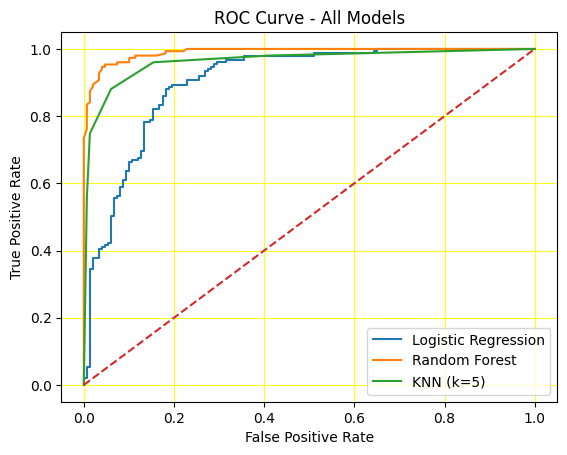

In [12]:
for name, model in models.items():
    if name in ["Logistic Regression", "KNN (k=5)"]:
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=name)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - All Models")
plt.legend()
plt.grid(True,alpha=0.9,color="yellow")
plt.show()